## Statistical Edge

##### Array -> Vector -> Time Series -> Matrices -> Multi-Variable Time Series -> Forecasting

##### Model -> Statistical Edge
##### Strategy -> Execution of Statistical Edge

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

### Matrix Algebra

In [2]:
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]

### Matrix-Scalar Algebra

In [3]:
# Matrix + 1, the manual way

no_rows = len(matrix)
no_columns = len(matrix[0])

for i in range(no_rows):
    for j in range(no_columns):
        matrix[i][j] += 1
matrix

[[2, 3, 4], [5, 6, 7], [8, 9, 10]]

In [4]:
# Numpy Matrix operations
np_matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
np_matrix

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [5]:
# Much faster in terms of performance
np_matrix + 1

array([[ 2,  3,  4],
       [ 5,  6,  7],
       [ 8,  9, 10]])

### Matrix-Vector Algebra


In [6]:
# Returns Matrix
X = np.array([[-0.1, -0.2], [-0.2, -0.4], [-0.4, -0.8]])
X

array([[-0.1, -0.2],
       [-0.2, -0.4],
       [-0.4, -0.8]])

In [7]:
# Weights Vector
w = np.array([-0.5, -0.1])
w

array([-0.5, -0.1])

In [8]:
# Dot product (Matrix multiplication with a Vector)
np.dot(X, w)

array([0.07, 0.14, 0.28])

In [9]:
# Behind the scenes it's doing this
w1 = w[0]
w2 = w[1]

np.array([-0.1 * w1 + -0.2 * w2, -0.2 * w1 + -0.4 * w2, -0.4 * w1 + -0.8 * w2])

array([0.07, 0.14, 0.28])

In [10]:
# Math of a Model
bias = b = 0.0001
np.dot(X, w) + b

array([0.0701, 0.1401, 0.2801])

Broadcasting != Matrix Multiplication

In [11]:
# NOT a matrix multiplication, this is broadcasting
X * w

array([[0.05, 0.02],
       [0.1 , 0.04],
       [0.2 , 0.08]])

### How to develop a Statistical Edge using Machine Learning

Statistical Edge == Good Forecast

In [12]:
# Download OHLC data for BTC-USD
url = 'https://drive.google.com/uc?export=download&id=1qnX9GpiL5Ii1FEnHTIAzWnxNejWnilKp'
btcusd = pd.read_csv(url, parse_dates=["open_time"], index_col='open_time')
btcusd

,open,high,low,close,volume
open_time,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299
...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325


In [13]:
btcusd['close_log_return'] = np.log(btcusd['close'] / btcusd['close'].shift())
btcusd['close_log_return_lag_1'] = btcusd['close_log_return'].shift()
btcusd['close_log_return_lag_2'] = btcusd['close_log_return'].shift(2)
btcusd['close_log_return_lag_3'] = btcusd['close_log_return'].shift(3)
btcusd

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474,NaN,NaN,NaN,NaN
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689,-0.005189,NaN,NaN,NaN
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837,-0.012063,-0.005189,NaN,NaN
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593,-0.001072,-0.012063,-0.005189,NaN
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-0.000263,-0.001072,-0.012063,-0.005189
...,...,...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.90,106000.00,105354.00,105767.20,2971.178,0.003138,-0.004455,0.006797,0.001525
2025-11-10 20:00:00,105767.10,106249.60,105750.30,105956.70,3483.547,0.001790,0.003138,-0.004455,0.006797
2025-11-10 21:00:00,105956.70,105973.90,105202.70,105583.50,3305.325,-0.003528,0.001790,0.003138,-0.004455


In [14]:
returns = btcusd[['close_log_return', 'close_log_return_lag_1', 'close_log_return_lag_2', 'close_log_return_lag_3']]
returns.corr()

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
close_log_return,1.000000,-0.005812,-0.012627,-0.001328
close_log_return_lag_1,-0.005812,1.000000,-0.005811,-0.012627
close_log_return_lag_2,-0.012627,-0.005811,1.000000,-0.005803
close_log_return_lag_3,-0.001328,-0.012627,-0.005803,1.000000


Inspect the data

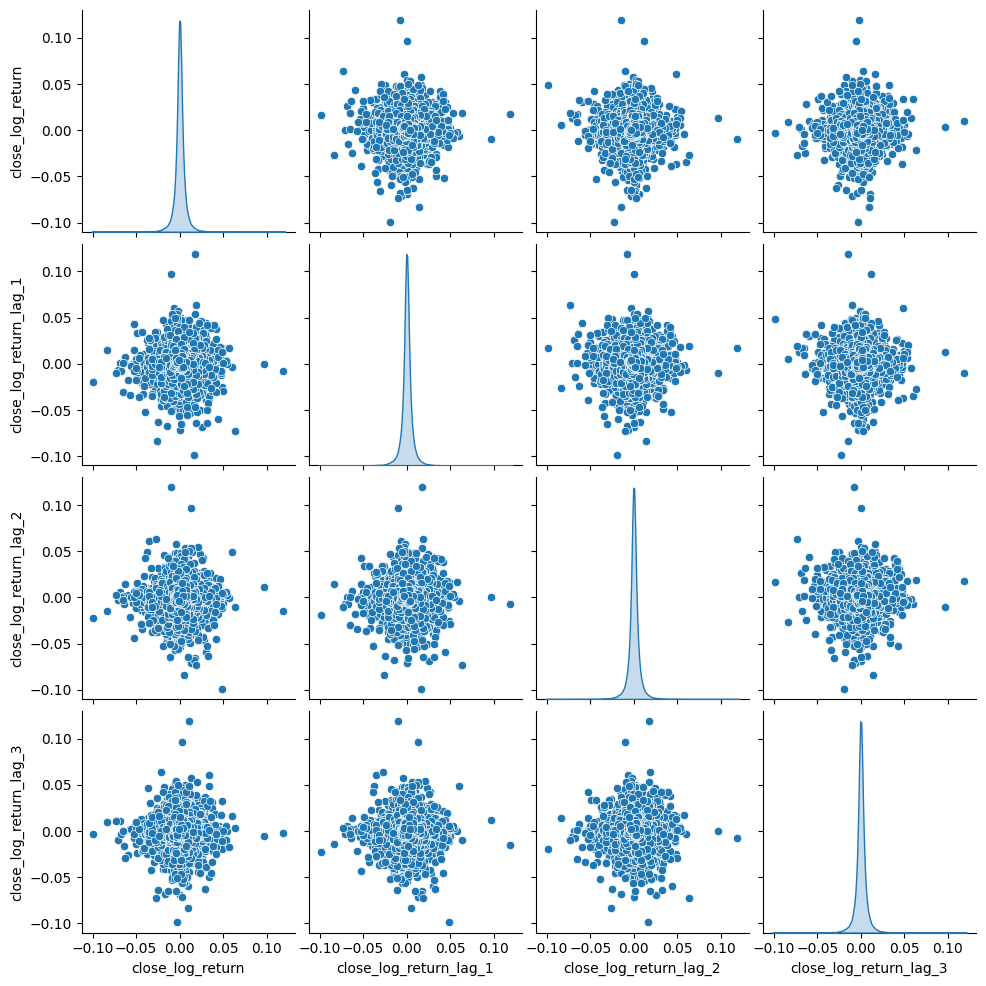

In [15]:
sns.pairplot(returns, diag_kind='kde')

In [16]:
# This converts the DataFrame to a Numpy matrix, which is what we need for our model
X = returns.dropna().values
X

array([[-0.00026285, -0.00107236, -0.01206327, -0.0051893 ],
       [ 0.01094601, -0.00026285, -0.00107236, -0.01206327],
       [ 0.00110898,  0.01094601, -0.00026285, -0.00107236],
       ...,
       [-0.00352841,  0.00179007,  0.00313822, -0.00445534],
       [ 0.00397283, -0.00352841,  0.00179007,  0.00313822],
       [-0.00035382,  0.00397283, -0.00352841,  0.00179007]],
      shape=(43436, 4))

### Forecasting: Regression

Split Training / Testing Data

In [17]:
# Time: t0 -> t1 -> t2 -> t3 -> t4 -> t5 -> t6 -> t7 -> t8 -> t9
# train: ---------------------------------|
# test:                                   |-------------------->

In [18]:
def time_split(x, train_size = 0.5):
    i = int(len(x) * train_size)
    return x[:i].copy(), x[i:].copy()

btcusd_train, btcusd_test = time_split(btcusd, train_size=0.7)

In [19]:
btcusd_train

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,,,,,,
2020-11-27 00:00:00,17155.37,17418.93,17024.20,17400.00,15427.474,NaN,NaN,NaN,NaN
2020-11-27 01:00:00,17401.51,17465.00,17271.30,17309.94,16632.689,-0.005189,NaN,NaN,NaN
2020-11-27 02:00:00,17309.93,17328.09,17072.80,17102.38,16168.837,-0.012063,-0.005189,NaN,NaN
2020-11-27 03:00:00,17102.10,17277.86,17029.32,17084.05,13670.593,-0.001072,-0.012063,-0.005189,NaN
2020-11-27 04:00:00,17084.05,17194.00,17061.00,17079.56,10866.299,-0.000263,-0.001072,-0.012063,-0.005189
...,...,...,...,...,...,...,...,...,...
2024-05-16 18:00:00,64976.70,65181.20,64808.00,65091.40,9827.579,0.001765,-0.002423,-0.010172,0.003392
2024-05-16 19:00:00,65091.50,65553.00,65062.70,65152.20,10280.552,0.000934,0.001765,-0.002423,-0.010172
2024-05-16 20:00:00,65152.30,65270.10,65018.70,65248.00,3804.218,0.001469,0.000934,0.001765,-0.002423


In [20]:
btcusd_test

,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
open_time,,,,,,,,,
2024-05-16 23:00:00,65389.1,65391.3,65162.1,65217.7,4410.460,-0.002626,-0.000610,0.002772,0.001469
2024-05-17 00:00:00,65217.7,65479.7,65213.7,65478.0,5542.829,0.003983,-0.002626,-0.000610,0.002772
2024-05-17 01:00:00,65477.9,65478.0,65061.2,65311.0,6160.987,-0.002554,0.003983,-0.002626,-0.000610
2024-05-17 02:00:00,65311.1,65430.0,65146.5,65351.5,4190.566,0.000620,-0.002554,0.003983,-0.002626
2024-05-17 03:00:00,65351.4,65850.0,65300.3,65545.2,11900.518,0.002960,0.000620,-0.002554,0.003983
...,...,...,...,...,...,...,...,...,...
2025-11-10 19:00:00,105435.9,106000.0,105354.0,105767.2,2971.178,0.003138,-0.004455,0.006797,0.001525
2025-11-10 20:00:00,105767.1,106249.6,105750.3,105956.7,3483.547,0.001790,0.003138,-0.004455,0.006797
2025-11-10 21:00:00,105956.7,105973.9,105202.7,105583.5,3305.325,-0.003528,0.001790,0.003138,-0.004455


Train Model

In [21]:
import random
import os

# 0. Reproducibility Settings
SEED = 99

# Ensure Python's hash-based operations are deterministic
os.environ["PYTHONHASHSEED"] = str(SEED)

# Set seeds for Python's built in RNG, NumPy, and PyTorch
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED) # For single-GPU setups
    torch.cuda.manual_seed_all(SEED) # For multi-GPU setups

# 1. Create Tensors from DataFrame after setting seeds

# Input features (model predictions)
features = ['close_log_return_lag_3']

# Target variable (model output)
target = 'close_log_return'

train_model_data = btcusd_train[[target, *features]].dropna()
test_model_data = btcusd_test[[target, *features]].dropna()

# Convert train/test splits into PyTorch tensors
X_train = torch.tensor(train_model_data[features].values, dtype=torch.float32)
X_test = torch.tensor(test_model_data[features].values, dtype=torch.float32)

# Create target tensors and add a column dimension (N -> N, 1)
y_train = torch.tensor(train_model_data[target].values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_model_data[target].values, dtype=torch.float32).unsqueeze(1)

assert torch.isfinite(X_train).all(), "X_train contains NaN or infinite values"
assert torch.isfinite(y_train).all(), "y_train contains NaN or infinite values"
assert torch.isfinite(X_test).all(), "X_test contains NaN or infinite values"
assert torch.isfinite(y_test).all(), "y_test contains NaN or infinite values"

print(f"Train rows: {len(train_model_data)}, Test rows: {len(test_model_data)}")

# 2. Define Model

# Number of input features
no_features = len(features)

# Simple linear regression model: y = W * x + b
model = nn.Linear(no_features, 1)

# Huber loss (robust to outliers compared to MSE)
criterion = nn.HuberLoss()

# Stochastic Gradient Descent optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 3. Training Loop (Full-Batch Gradient Descent)
TRAIN_SIZE = 5000
for epoch in range(TRAIN_SIZE):

    # Clear previous stored gradients (they accumulate by default)
    optimizer.zero_grad()

    # Forward pass: compute predictions
    y_pred = model(X_train)

    # Compute loss between predictions and true values
    loss = criterion(y_pred, y_train)

    # Backpropagation: compute gradients of loss w.r.t. parameters
    loss.backward()

    # Update model parameters using the computed gradients
    optimizer.step()

    # Print loss every 500 epochs
    if epoch % 500 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

# 4. Check trained parameters
print("Final weight:", model.weight.data)
print("Final bias:", model.bias.data)

Train rows: 30403, Test rows: 13033
Epoch: 0 Loss: 0.44205936789512634
Epoch: 500 Loss: 5.928735845373012e-05
Epoch: 1000 Loss: 4.019748666905798e-05
Epoch: 1500 Loss: 4.0188497223425657e-05
Epoch: 2000 Loss: 4.0180329961003736e-05
Epoch: 2500 Loss: 4.017216633656062e-05
Epoch: 3000 Loss: 4.0164006350096315e-05
Epoch: 3500 Loss: 4.01558427256532e-05
Epoch: 4000 Loss: 4.01476863771677e-05
Epoch: 4500 Loss: 4.013952275272459e-05
Final weight: tensor([[-0.7913]])
Final bias: tensor([7.8514e-05])


In [22]:
torch.save(model.state_dict(), "model.pth")

### Evaluate the model (Out-Of-Sample)

In [23]:
w = model.weight
b = model.bias.item()
y_hat = model(X_test)
y_hat

tensor([[-0.0011],
        [-0.0021],
        [ 0.0006],
        ...,
        [ 0.0036],
        [-0.0024],
        [-0.0013]], grad_fn=<AddmmBackward0>)

In [24]:
y_hat.detach(), y_hat.detach().squeeze()

(tensor([[-0.0011],
         [-0.0021],
         [ 0.0006],
         ...,
         [ 0.0036],
         [-0.0024],
         [-0.0013]]),
 tensor([-0.0011, -0.0021,  0.0006,  ...,  0.0036, -0.0024, -0.0013]))

In [25]:
btcusd_test['y_hat'] = y_hat.detach().squeeze()
btcusd_test[['close_log_return', 'y_hat']]

,close_log_return,y_hat
open_time,,
2024-05-16 23:00:00,-0.002626,-0.001084
2024-05-17 00:00:00,0.003983,-0.002115
2024-05-17 01:00:00,-0.002554,0.000561
2024-05-17 02:00:00,0.000620,0.002157
2024-05-17 03:00:00,0.002960,-0.003074
...,...,...
2025-11-10 19:00:00,0.003138,-0.001128
2025-11-10 20:00:00,0.001790,-0.005300
2025-11-10 21:00:00,-0.003528,0.003604


### Directional Signal

In [26]:
btcusd_test['dir_signal'] = np.sign(btcusd_test['y_hat'])
btcusd_test[['close_log_return', 'y_hat', 'dir_signal']]

,close_log_return,y_hat,dir_signal
open_time,,,
2024-05-16 23:00:00,-0.002626,-0.001084,-1.0
2024-05-17 00:00:00,0.003983,-0.002115,-1.0
2024-05-17 01:00:00,-0.002554,0.000561,1.0
2024-05-17 02:00:00,0.000620,0.002157,1.0
2024-05-17 03:00:00,0.002960,-0.003074,-1.0
...,...,...,...
2025-11-10 19:00:00,0.003138,-0.001128,-1.0
2025-11-10 20:00:00,0.001790,-0.005300,-1.0
2025-11-10 21:00:00,-0.003528,0.003604,1.0


### Directional Accuracy (DA)

In [27]:
btcusd_test['is_won'] = btcusd_test['dir_signal'] == np.sign(btcusd_test['close_log_return'])
btcusd_test[['close_log_return', 'y_hat', 'dir_signal', 'is_won']]

,close_log_return,y_hat,dir_signal,is_won
open_time,,,,
2024-05-16 23:00:00,-0.002626,-0.001084,-1.0,True
2024-05-17 00:00:00,0.003983,-0.002115,-1.0,False
2024-05-17 01:00:00,-0.002554,0.000561,1.0,False
2024-05-17 02:00:00,0.000620,0.002157,1.0,True
2024-05-17 03:00:00,0.002960,-0.003074,-1.0,False
...,...,...,...,...
2025-11-10 19:00:00,0.003138,-0.001128,-1.0,False
2025-11-10 20:00:00,0.001790,-0.005300,-1.0,False
2025-11-10 21:00:00,-0.003528,0.003604,1.0,False


In [28]:
da = btcusd_test['is_won'].mean()
da

np.float64(0.5074810097444947)

In [29]:
btcusd_test['is_won'].value_counts()

is_won
True     6614
False    6419
Name: count, dtype: int64

### Trade Returns

In [30]:
btcusd_test['trade_log_return'] = btcusd_test['dir_signal'] * btcusd_test['close_log_return']
btcusd_test['trade_log_return']

open_time
2024-05-16 23:00:00    0.002626
2024-05-17 00:00:00   -0.003983
2024-05-17 01:00:00   -0.002554
2024-05-17 02:00:00    0.000620
2024-05-17 03:00:00   -0.002960
                         ...   
2025-11-10 19:00:00   -0.003138
2025-11-10 20:00:00   -0.001790
2025-11-10 21:00:00   -0.003528
2025-11-10 22:00:00   -0.003973
2025-11-10 23:00:00    0.000354
Name: trade_log_return, Length: 13033, dtype: float64

### Statistical Edge

In [31]:
statistical_edge = btcusd_test['trade_log_return'].mean()
has_statistical_edge = statistical_edge > 0
has_statistical_edge, statistical_edge

(np.True_, np.float64(7.932888266117073e-05))

### Total Return

In [32]:
btcusd_test['trade_log_return'].sum()

np.float64(1.033893327723038)

In [35]:
# This is the multiplicative factor of the returns, so if it's above 1 we have a positive return, if it's below 1 we have a negative return
mult_factor = np.exp(btcusd_test['trade_log_return'].sum())
mult_factor

np.float64(2.8119925588240755)

In [36]:
initial_balance = 100
final_balance = initial_balance * mult_factor
final_balance

np.float64(281.19925588240756)

### Equity Curve

In [37]:
cum_trade_log_return = btcusd_test['trade_log_return'].cumsum()
cum_trade_log_return

open_time
2024-05-16 23:00:00    0.002626
2024-05-17 00:00:00   -0.001357
2024-05-17 01:00:00   -0.003911
2024-05-17 02:00:00   -0.003291
2024-05-17 03:00:00   -0.006251
                         ...   
2025-11-10 19:00:00    1.042831
2025-11-10 20:00:00    1.041041
2025-11-10 21:00:00    1.037512
2025-11-10 22:00:00    1.033540
2025-11-10 23:00:00    1.033893
Name: trade_log_return, Length: 13033, dtype: float64

<Axes: xlabel='open_time'>

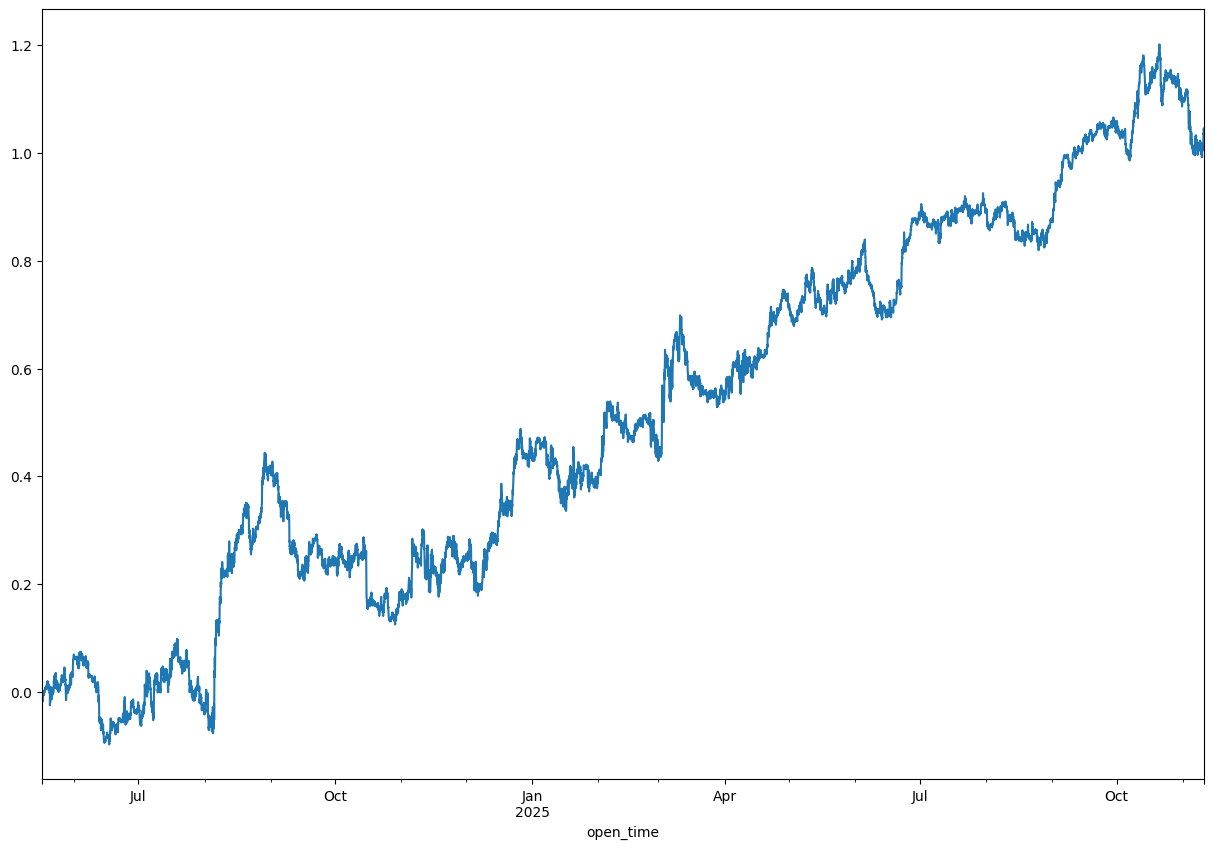

In [38]:
cum_trade_log_return.plot(figsize=(15, 10))

### Sharpe Ratio
Returns / Risk

In [43]:
mean = btcusd_test['trade_log_return'].mean()
std = btcusd_test['trade_log_return'].std()
sharpe_ratio = mean / std
sharpe_ratio

np.float64(0.015930382069258217)

### Annualization

In [44]:
# Annualize Sharpe Ratio, because this model is trading on hourly based
no_trading_days_in_year = 365
no_hours_in_day = 24
t = no_trading_days_in_year * no_hours_in_day

sharpe_ratio = mean / std * np.sqrt(t)
sharpe_ratio, mean, std

(np.float64(1.491002065177471),
 np.float64(7.932888266117073e-05),
 np.float64(0.004979722540004629))

### Net Returns (inc. Trade Fees)
1) Taker -> No Alpha -> Fees will decay the edge -> Win values reduced -> Loss values Amplified -> Positive EV turns to negative EV
2) Maker -> Alpha -> Fees very low and even negative (paid to add liquidity) -> Positive EV stays positive (Depends on Exchange/Broker)